In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings("ignore")

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])
X = df.drop('Survived', axis=1)
y = df['Survived']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (712, 7)
Test set shape: (179, 7)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_preds)

print(f"Logistic Regression Test Accuracy: {lr_accuracy*100:.2f}%")

Logistic Regression Test Accuracy: 79.89%


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model = LinearDiscriminantAnalysis()

lda_model.fit(X_train, y_train)

lda_preds = lda_model.predict(X_test)

lda_accuracy = accuracy_score(y_test, lda_preds)

print(f"LDA Test Accuracy: {lda_accuracy*100:.2f}%")


LDA Test Accuracy: 79.33%


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"k-NN Classification Accuracy: {knn_accuracy*100:.2f}%")

k-NN Classification Accuracy: 81.01%


In [ ]:
comparison_df = pd.DataFrame({
    'Supervised Classifier': [
        'Logistic Regression',
        'Linear Discriminant Analysis (LDA)',
        'k-Nearest Neighbors (k-NN)'
    ],
    'Test Accuracy (%)': [
        lr_accuracy * 100,
        lda_accuracy * 100,
        knn_accuracy * 100
    ]
})

print("\n--- Performance Comparison on Titanic Dataset ---")
print(comparison_df.to_string(index=False))


--- Performance Comparison on Titanic Dataset ---
             Supervised Classifier  Test Accuracy (%)
               Logistic Regression          79.888268
Linear Discriminant Analysis (LDA)          79.329609
        k-Nearest Neighbors (k-NN)          81.005587


In [ ]:
#TASK-2
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_preds)

print(f"Gaussian Naïve Bayes Test Accuracy: {nb_accuracy*100:.2f}%")

Gaussian Naïve Bayes Test Accuracy: 78.21%


In [ ]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear', probability=True, random_state=42)

svm_linear.fit(X_train, y_train)

linear_preds = svm_linear.predict(X_test)

linear_accuracy = accuracy_score(y_test, linear_preds)

print(f"Linear Kernel SVM Test Accuracy: {linear_accuracy*100:.2f}%")


Linear Kernel SVM Test Accuracy: 77.65%


In [ ]:
#TASK-3
comparison_df = pd.DataFrame({
    'Classifier': [
        'Gaussian Naïve Bayes',
        'Linear Kernel SVM'
    ],
    'Test Accuracy (%)': [
        nb_accuracy * 100,
        linear_accuracy * 100
    ]
})

print("\n--- Performance Comparison on Titanic Dataset ---")
print(comparison_df.to_string(index=False))



--- Performance Comparison on Titanic Dataset ---
          Classifier  Test Accuracy (%)
Gaussian Naïve Bayes          78.212291
   Linear Kernel SVM          77.653631


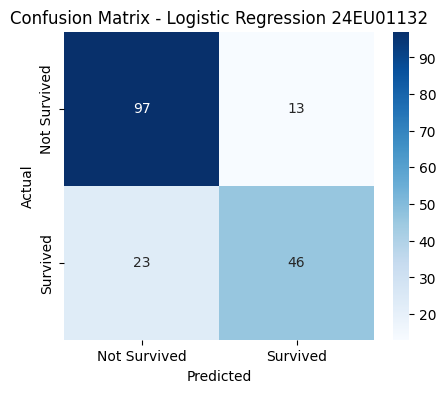

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, lr_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True,fmt='d',cmap='Blues',xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived'])
plt.title("Confusion Matrix - Logistic Regression 24EU01132")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    lr_preds,
    target_names=['Not Survived', 'Survived']
)

print("--- Logistic Regression Classification Report ---")
print(report)


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

Not Survived       0.81      0.88      0.84       110
    Survived       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



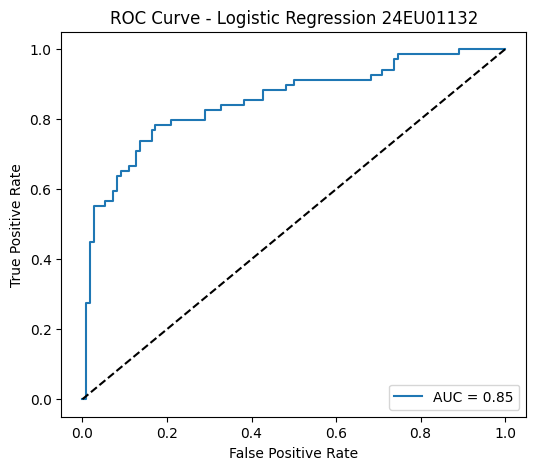

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
y_score = lr_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression 24EU01132")
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np
lr_model = LogisticRegression(random_state=42)
cv_scores = cross_val_score(
    lr_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)
print("5-Fold Cross-Validation Accuracy:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")
print("\nMean Accuracy: {:.2f}%".format(np.mean(cv_scores)*100))
print("Standard Deviation: {:.2f}%".format(np.std(cv_scores)*100))


5-Fold Cross-Validation Accuracy:
Fold 1: 0.7709
Fold 2: 0.7865
Fold 3: 0.7809
Fold 4: 0.7640
Fold 5: 0.8202

Mean Accuracy: 78.45%
Standard Deviation: 1.95%
